# Projeto 09 — TSP com algoritmos de otimização

**Disciplina:** Algoritmos e Programação — IA para Engenheiros  
**Tema:** Otimização aplicada ao Problema do Caixeiro Viajante (TSP)
**Nome: Giovanni Souza de Andrade

Este notebook implementa, em código próprio, algoritmos vistos nas aulas de otimização:

1. **Guloso / Nearest Neighbor**
2. **Hill Climbing com 2-opt**
3. **Simulated Annealing**
4. **Threshold Accepting**
5. **Algoritmo Genético com Order Crossover e mutação swap**
6. **OBS: Uso do ChatGPT, Codex, Claude para ajuda na implementação, correção e explicação do codigo**

O objetivo é resolver benchmarks da **TSPLIB95**, registrar os resultados em uma tabela e salvar a comparação em arquivo `.csv`.

## 1. Instalação e imports

Execute a instalação abaixo apenas se o pacote `tsplib95` ainda não estiver instalado no ambiente.

In [ ]:

from __future__ import annotations

import math
import random
import time
import urllib.request
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import tsplib95
import pandas as pd
import matplotlib.pyplot as plt

## 2. Configuração geral

A pasta `benchmarks_tsplib` será usada para armazenar os arquivos `.tsp`.

O código tenta baixar os arquivos do repositório indicado no enunciado. Caso esteja sem internet, baixe manualmente os arquivos `.tsp` e coloque nessa pasta.

In [ ]:
SEMENTE = 42
random.seed(SEMENTE)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "benchmarks_tsplib"
RESULTADOS_CSV = BASE_DIR / "resultados_projeto09_tsp.csv"

DATA_DIR.mkdir(parents=True, exist_ok=True)

# Benchmarks sugeridos para a entrega.
BENCHMARKS = [
    "burma14.tsp",
    "berlin52.tsp",
    "kroA100.tsp",
]

# Escolhi esses para calcular o gap percentual.
OTIMOS_CONHECIDOS = {
    "burma14": 3323,
    "berlin52": 7542,
    "kroA100": 21282,
}

# Repositório citado no enunciado.
TSPLIB_RAW_BASE = "https://raw.githubusercontent.com/mastqe/tsplib/master"

## 3. Download dos benchmarks

A função abaixo baixa os arquivos `.tsp` apenas se eles ainda não existirem localmente.

In [3]:
def baixar_benchmark(nome_arquivo: str, destino: Path = DATA_DIR) -> Path:
    """Baixa um benchmark .tsp do repositório indicado no enunciado."""
    caminho = destino / nome_arquivo

    if caminho.exists():
        print(f"Arquivo já existe: {caminho}")
        return caminho

    url = f"{TSPLIB_RAW_BASE}/{nome_arquivo}"
    print(f"Baixando {nome_arquivo}...")
    try:
        urllib.request.urlretrieve(url, caminho)
        print(f"Salvo em: {caminho}")
    except Exception as erro:
        print(f"Não foi possível baixar {nome_arquivo}.")
        print("Coloque o arquivo manualmente na pasta:", destino)
        print("Erro:", erro)

    return caminho


def preparar_benchmarks(lista_benchmarks: list[str]) -> list[Path]:
    """Garante que os benchmarks estejam disponíveis e retorna os caminhos existentes."""
    caminhos = []

    for nome in lista_benchmarks:
        caminho = baixar_benchmark(nome)
        if caminho.exists():
            caminhos.append(caminho)
        else:
            print(f"Atenção: {nome} não foi encontrado e será ignorado.")

    return caminhos

## 4. Parser TSPLIB95 e funções utilitárias

Aqui está o parser solicitado no enunciado:

```python
prob = tsplib95.load('berlin52.tsp')
nos = list(prob.get_nodes())
```

Além disso, o código cria uma **matriz de distâncias**, pois isso acelera a execução dos algoritmos.

In [5]:
@dataclass
class ProblemaTSP:
    nome: str
    prob: object
    nos: list
    n: int
    dist: list[list[float]]
    coords: dict[int, tuple[float, float]] | None


def carregar_problema_tsp(arquivo: Path) -> ProblemaTSP:
    """Carrega um arquivo .tsp usando tsplib95 e prepara matriz de distâncias."""

    # Parser pedido no enunciado:
    prob = tsplib95.load(str(arquivo))
    nos = list(prob.get_nodes())

    n = len(nos)
    dist = [[0.0] * n for _ in range(n)]

    for i, a in enumerate(nos):
        for j, b in enumerate(nos):
            if i != j:
                dist[i][j] = float(prob.get_weight(a, b))

    coords = None
    if getattr(prob, "node_coords", None):
        coords = {i: prob.node_coords[nos[i]] for i in range(n)}

    return ProblemaTSP(
        nome=arquivo.stem,
        prob=prob,
        nos=nos,
        n=n,
        dist=dist,
        coords=coords,
    )


def distancia_tour(tour: list[int], dist: list[list[float]]) -> float:
    """Calcula a distância total de um tour fechado."""
    return sum(dist[tour[i]][tour[(i + 1) % len(tour)]] for i in range(len(tour)))


def gap_percentual(distancia: float, otimo: float | None) -> float | None:
    """Calcula o gap percentual em relação ao ótimo conhecido."""
    if otimo is None:
        return None
    return 100.0 * (distancia - otimo) / otimo


def tour_em_rotulo_tsplib(tour: list[int], nos: list) -> str:
    """Converte índices internos 0..n-1 para os rótulos originais da TSPLIB."""
    tour_fechado = tour + [tour[0]]
    return " -> ".join(str(nos[i]) for i in tour_fechado)


def plotar_tour(problema: ProblemaTSP, tour: list[int], titulo: str) -> None:
    """Plota o tour quando o benchmark possui coordenadas."""
    if problema.coords is None:
        print("Este benchmark não possui coordenadas para plot.")
        return

    coords = problema.coords
    xs = [coords[i][0] for i in tour] + [coords[tour[0]][0]]
    ys = [coords[i][1] for i in tour] + [coords[tour[0]][1]]

    plt.figure(figsize=(8, 6))
    plt.plot(xs, ys, marker="o", linewidth=1)
    for i in tour:
        plt.annotate(str(problema.nos[i]), (coords[i][0], coords[i][1]), textcoords="offset points", xytext=(5, 5))

    plt.title(f"{titulo}\nDistância = {distancia_tour(tour, problema.dist):.2f}")
    plt.xlabel("Coordenada x / Longitude")
    plt.ylabel("Coordenada y / Latitude")
    plt.grid(True, linewidth=0.4, alpha=0.5)
    plt.show()

## 5. Algoritmo 1 — Guloso / Nearest Neighbor

O algoritmo guloso constrói a rota escolhendo sempre a cidade não visitada mais próxima da cidade atual.

Para melhorar o resultado, foi implementado o **multi-start**: o algoritmo é testado iniciando em várias cidades, e fica com a melhor rota encontrada.

In [6]:
def nearest_neighbor(n: int, dist: list[list[float]], inicio: int = 0) -> list[int]:
    """Constrói um tour pela regra do vizinho mais próximo."""
    visitado = [False] * n
    tour = [inicio]
    visitado[inicio] = True
    atual = inicio

    for _ in range(n - 1):
        proximo = min(
            (j for j in range(n) if not visitado[j]),
            key=lambda j: dist[atual][j],
        )
        tour.append(proximo)
        visitado[proximo] = True
        atual = proximo

    return tour


def guloso_multistart(n: int, dist: list[list[float]], max_inicios: int | None = None) -> list[int]:
    """Executa Nearest Neighbor a partir de vários pontos iniciais."""
    if max_inicios is None:
        inicios = range(n)
    else:
        inicios = range(min(n, max_inicios))

    melhor = None
    melhor_distancia = float("inf")

    for inicio in inicios:
        tour = nearest_neighbor(n, dist, inicio=inicio)
        d = distancia_tour(tour, dist)
        if d < melhor_distancia:
            melhor = tour
            melhor_distancia = d

    return melhor

## 6. Algoritmo 2 — Hill Climbing com 2-opt

O Hill Climbing parte de uma solução inicial e aceita apenas modificações que melhoram a rota.

Neste projeto, o vizinho é gerado por **2-opt**, que remove duas arestas e reconecta o trajeto invertendo um trecho da rota.

In [7]:
def two_opt_hill_climbing(
    tour_inicial: list[int],
    dist: list[list[float]],
    max_passes: int = 200,
) -> list[int]:
    """Busca local por 2-opt. Aceita apenas trocas que reduzem a distância."""
    melhor = tour_inicial[:]
    n = len(melhor)

    for _ in range(max_passes):
        melhorou = False

        for i in range(1, n - 1):
            for j in range(i + 1, n):
                a, b = melhor[i - 1], melhor[i]
                c, d = melhor[j], melhor[(j + 1) % n]

                delta = (dist[a][c] + dist[b][d]) - (dist[a][b] + dist[c][d])

                if delta < -1e-9:
                    melhor[i : j + 1] = reversed(melhor[i : j + 1])
                    melhorou = True

        if not melhorou:
            break

    return melhor

## 7. Algoritmo 3 — Simulated Annealing

O Simulated Annealing é parecido com o Hill Climbing, mas pode aceitar soluções piores com certa probabilidade.

Essa característica ajuda o algoritmo a escapar de mínimos locais.

In [8]:
def vizinho_2opt_aleatorio(tour: list[int]) -> list[int]:
    """Gera um vizinho aleatório por inversão de trecho 2-opt."""
    if len(tour) < 4:
        return tour[:]

    novo = tour[:]
    i, j = sorted(random.sample(range(1, len(tour)), 2))
    novo[i : j + 1] = reversed(novo[i : j + 1])
    return novo


def simulated_annealing(
    tour_inicial: list[int],
    dist: list[list[float]],
    temperatura: float = 1000.0,
    alpha: float = 0.995,
    temperatura_min: float = 1e-3,
    max_iter: int = 50_000,
) -> list[int]:
    """Recozimento simulado para minimizar a distância do TSP."""
    atual = tour_inicial[:]
    custo_atual = distancia_tour(atual, dist)

    melhor = atual[:]
    melhor_custo = custo_atual

    for _ in range(max_iter):
        if temperatura <= temperatura_min:
            break

        candidato = vizinho_2opt_aleatorio(atual)
        custo_candidato = distancia_tour(candidato, dist)
        delta = custo_candidato - custo_atual

        # Se melhorou, aceita.
        # Se piorou, aceita com probabilidade exp(-delta/T).
        if delta < 0 or random.random() < math.exp(-delta / temperatura):
            atual = candidato
            custo_atual = custo_candidato

            if custo_atual < melhor_custo:
                melhor = atual[:]
                melhor_custo = custo_atual

        temperatura *= alpha

    return melhor

## 8. Algoritmo 4 — Threshold Accepting

O Threshold Accepting é semelhante ao Simulated Annealing, mas aceita uma solução pior quando a piora é menor que um limiar.

Esse limiar diminui ao longo do tempo.

In [9]:
def threshold_accepting(
    tour_inicial: list[int],
    dist: list[list[float]],
    theta: float = 100.0,
    alpha: float = 0.995,
    theta_min: float = 1e-3,
    max_iter: int = 50_000,
) -> list[int]:
    """Threshold Accepting para minimizar a distância do TSP."""
    atual = tour_inicial[:]
    custo_atual = distancia_tour(atual, dist)

    melhor = atual[:]
    melhor_custo = custo_atual

    for _ in range(max_iter):
        if theta <= theta_min:
            break

        candidato = vizinho_2opt_aleatorio(atual)
        custo_candidato = distancia_tour(candidato, dist)
        delta = custo_candidato - custo_atual

        # Aceita se melhorou ou se a piora está dentro do limiar.
        if delta <= theta:
            atual = candidato
            custo_atual = custo_candidato

            if custo_atual < melhor_custo:
                melhor = atual[:]
                melhor_custo = custo_atual

        theta *= alpha

    return melhor

## 9. Algoritmo 5 — Algoritmo Genético

No TSP, cada indivíduo é uma permutação de cidades.

Exemplo:

```python
[0, 3, 1, 4, 2]
```

Isso significa visitar as cidades nessa ordem.

Operadores usados:

- **Seleção por torneio**
- **Order Crossover (OX)**
- **Mutação swap**
- **Elitismo**

In [10]:
def selecao_torneio(populacao: list[list[int]], custos: list[float], k: int = 3) -> list[int]:
    """Seleciona o melhor indivíduo entre k candidatos sorteados."""
    candidatos = random.sample(range(len(populacao)), k)
    melhor_idx = min(candidatos, key=lambda idx: custos[idx])
    return populacao[melhor_idx][:]


def order_crossover(pai1: list[int], pai2: list[int]) -> list[int]:
    """Order Crossover para permutações, adequado para TSP."""
    n = len(pai1)
    a, b = sorted(random.sample(range(n), 2))

    filho = [-1] * n
    filho[a : b + 1] = pai1[a : b + 1]

    pos = (b + 1) % n
    for gene in pai2:
        if gene in filho:
            continue
        filho[pos] = gene
        pos = (pos + 1) % n

    return filho


def mutacao_swap(individuo: list[int], taxa: float = 0.02) -> list[int]:
    """Mutação por troca de posições."""
    filho = individuo[:]

    for i in range(len(filho)):
        if random.random() < taxa:
            j = random.randrange(len(filho))
            filho[i], filho[j] = filho[j], filho[i]

    return filho


def algoritmo_genetico(
    n: int,
    dist: list[list[float]],
    pop_size: int = 120,
    geracoes: int = 500,
    taxa_crossover: float = 0.90,
    taxa_mutacao: float = 0.02,
    elitismo: int = 2,
) -> tuple[list[int], list[float], list[float]]:
    """Algoritmo Genético para TSP."""
    base = list(range(n))

    # População inicial aleatória.
    populacao = [random.sample(base, n) for _ in range(pop_size)]

    # Semeia parte da população com soluções gulosas para acelerar a convergência.
    for inicio in range(min(n, max(1, pop_size // 10))):
        populacao[inicio] = nearest_neighbor(n, dist, inicio=inicio)

    historico_melhor = []
    historico_medio = []

    for _ in range(geracoes):
        custos = [distancia_tour(ind, dist) for ind in populacao]
        historico_melhor.append(min(custos))
        historico_medio.append(sum(custos) / len(custos))

        ordem = sorted(range(pop_size), key=lambda idx: custos[idx])
        nova_populacao = [populacao[idx][:] for idx in ordem[:elitismo]]

        while len(nova_populacao) < pop_size:
            pai1 = selecao_torneio(populacao, custos)
            pai2 = selecao_torneio(populacao, custos)

            if random.random() < taxa_crossover:
                filho = order_crossover(pai1, pai2)
            else:
                filho = pai1[:]

            filho = mutacao_swap(filho, taxa_mutacao)
            nova_populacao.append(filho)

        populacao = nova_populacao

    custos = [distancia_tour(ind, dist) for ind in populacao]
    melhor_idx = min(range(pop_size), key=lambda idx: custos[idx])
    melhor = populacao[melhor_idx]

    return melhor, historico_melhor, historico_medio

## 10. Funções de experimento e tabela de resultados

A função abaixo executa todos os algoritmos para cada benchmark e registra:

- Nome do benchmark
- Dimensão
- Algoritmo
- Distância encontrada
- Ótimo conhecido
- Gap percentual
- Tempo de execução
- Tour encontrado

In [11]:
def parametros_por_tamanho(n: int) -> dict:
    """Define esforço computacional conforme o tamanho da instância."""
    if n <= 30:
        return {
            "sa_iter": 20_000,
            "ta_iter": 20_000,
            "ga_pop": 80,
            "ga_ger": 300,
        }

    if n <= 100:
        return {
            "sa_iter": 50_000,
            "ta_iter": 50_000,
            "ga_pop": 140,
            "ga_ger": 700,
        }

    return {
        "sa_iter": 80_000,
        "ta_iter": 80_000,
        "ga_pop": 180,
        "ga_ger": 900,
    }


def registrar_resultado(
    problema: ProblemaTSP,
    algoritmo: str,
    tour: list[int],
    tempo_s: float,
    otimo: float | None,
) -> dict:
    """Monta uma linha da tabela de resultados."""
    distancia = distancia_tour(tour, problema.dist)

    return {
        "benchmark": problema.nome,
        "dimensao": problema.n,
        "edge_weight_type": getattr(problema.prob, "edge_weight_type", None),
        "algoritmo": algoritmo,
        "distancia": round(distancia, 3),
        "otimo_conhecido": otimo,
        "gap_percentual": None if otimo is None else round(gap_percentual(distancia, otimo), 3),
        "tempo_s": round(tempo_s, 4),
        "tour": tour_em_rotulo_tsplib(tour, problema.nos),
    }


def medir(
    problema: ProblemaTSP,
    algoritmo: str,
    funcao: Callable[[], list[int]],
    otimo: float | None,
) -> tuple[dict, list[int]]:
    """Executa uma função de otimização medindo o tempo."""
    t0 = time.perf_counter()
    tour = funcao()
    tempo_s = time.perf_counter() - t0

    linha = registrar_resultado(
        problema=problema,
        algoritmo=algoritmo,
        tour=tour,
        tempo_s=tempo_s,
        otimo=otimo,
    )

    return linha, tour


def resolver_benchmark(arquivo: Path, semente: int = SEMENTE) -> tuple[list[dict], dict[str, list]]:
    """Resolve um benchmark com todos os algoritmos."""
    random.seed(semente)

    problema = carregar_problema_tsp(arquivo)
    otimo = OTIMOS_CONHECIDOS.get(problema.nome)
    pars = parametros_por_tamanho(problema.n)

    print(f"\nBenchmark: {problema.nome} | dimensão: {problema.n}")

    resultados = []
    tours = {}

    # 1. Guloso.
    linha, tour_guloso = medir(
        problema,
        "Guloso - Nearest Neighbor",
        lambda: guloso_multistart(problema.n, problema.dist),
        otimo,
    )
    resultados.append(linha)
    tours["guloso"] = tour_guloso

    # 2. Hill Climbing 2-opt, partindo do guloso.
    linha, tour_2opt = medir(
        problema,
        "Hill Climbing - 2-opt",
        lambda: two_opt_hill_climbing(tour_guloso, problema.dist),
        otimo,
    )
    resultados.append(linha)
    tours["2opt"] = tour_2opt

    # 3. Simulated Annealing, partindo do 2-opt.
    linha, tour_sa = medir(
        problema,
        "Simulated Annealing",
        lambda: simulated_annealing(
            tour_2opt,
            problema.dist,
            max_iter=pars["sa_iter"],
        ),
        otimo,
    )
    resultados.append(linha)
    tours["sa"] = tour_sa

    # 4. Threshold Accepting, partindo do 2-opt.
    linha, tour_ta = medir(
        problema,
        "Threshold Accepting",
        lambda: threshold_accepting(
            tour_2opt,
            problema.dist,
            max_iter=pars["ta_iter"],
        ),
        otimo,
    )
    resultados.append(linha)
    tours["ta"] = tour_ta

    # 5. Algoritmo Genético.
    historico_ag = {"melhor": [], "medio": []}

    def executar_ag():
        melhor, hist_melhor, hist_medio = algoritmo_genetico(
            problema.n,
            problema.dist,
            pop_size=pars["ga_pop"],
            geracoes=pars["ga_ger"],
        )
        historico_ag["melhor"] = hist_melhor
        historico_ag["medio"] = hist_medio
        return melhor

    linha, tour_ag = medir(
        problema,
        "Algoritmo Genético - OX + swap",
        executar_ag,
        otimo,
    )
    resultados.append(linha)
    tours["ag"] = tour_ag
    tours["historico_ag"] = historico_ag

    return resultados, tours

## 11. Executar todos os benchmarks

Esta célula gera a tabela final e salva o arquivo `resultados_projeto09_tsp.csv`.

In [12]:
caminhos = preparar_benchmarks(BENCHMARKS)

todos_resultados = []
todos_tours = {}

for caminho in caminhos:
    resultados, tours = resolver_benchmark(caminho)
    todos_resultados.extend(resultados)
    todos_tours[caminho.stem] = tours

tabela_resultados = pd.DataFrame(todos_resultados)

colunas_resumo = [
    "benchmark",
    "dimensao",
    "algoritmo",
    "distancia",
    "otimo_conhecido",
    "gap_percentual",
    "tempo_s",
]

display(tabela_resultados[colunas_resumo])

tabela_resultados.to_csv(RESULTADOS_CSV, index=False, encoding="utf-8-sig")
print(f"Resultados salvos em: {RESULTADOS_CSV}")

Baixando burma14.tsp...
Salvo em: c:\Users\GSA\Workspace\ALGORITMOS_IA\CURSO_IA\APE_ALGOR_PROGRAMACAO\benchmarks_tsplib\burma14.tsp
Baixando berlin52.tsp...
Salvo em: c:\Users\GSA\Workspace\ALGORITMOS_IA\CURSO_IA\APE_ALGOR_PROGRAMACAO\benchmarks_tsplib\berlin52.tsp
Baixando kroA100.tsp...
Salvo em: c:\Users\GSA\Workspace\ALGORITMOS_IA\CURSO_IA\APE_ALGOR_PROGRAMACAO\benchmarks_tsplib\kroA100.tsp

Benchmark: burma14 | dimensão: 14

Benchmark: berlin52 | dimensão: 52

Benchmark: kroA100 | dimensão: 100


,benchmark,dimensao,algoritmo,distancia,otimo_conhecido,gap_percentual,tempo_s
0,burma14,14,Guloso - Nearest Neighbor,3841.0,3323,15.588,0.0005
1,burma14,14,Hill Climbing - 2-opt,3323.0,3323,0.000,0.0001
2,burma14,14,Simulated Annealing,3323.0,3323,0.000,0.0170
3,burma14,14,Threshold Accepting,3323.0,3323,0.000,0.0134
4,burma14,14,Algoritmo Genético - OX + swap,3323.0,3323,0.000,0.4903
5,berlin52,52,Guloso - Nearest Neighbor,8181.0,7542,8.473,0.0146
6,berlin52,52,Hill Climbing - 2-opt,7542.0,7542,0.000,0.0010
7,berlin52,52,Simulated Annealing,7542.0,7542,0.000,0.0344
8,berlin52,52,Threshold Accepting,7542.0,7542,0.000,0.0281
9,berlin52,52,Algoritmo Genético - OX + swap,8806.0,7542,16.759,4.5992


Resultados salvos em: c:\Users\GSA\Workspace\ALGORITMOS_IA\CURSO_IA\APE_ALGOR_PROGRAMACAO\resultados_projeto09_tsp.csv


## 12. Melhor algoritmo por benchmark

Esta tabela resume o melhor resultado encontrado em cada instância.

In [13]:
if not tabela_resultados.empty:
    idx = tabela_resultados.groupby("benchmark")["distancia"].idxmin()
    melhores_por_benchmark = tabela_resultados.loc[idx, colunas_resumo].sort_values("benchmark")
    display(melhores_por_benchmark)
else:
    print("Nenhum resultado disponível.")

,benchmark,dimensao,algoritmo,distancia,otimo_conhecido,gap_percentual,tempo_s
6,berlin52,52,Hill Climbing - 2-opt,7542.0,7542,0.00,0.0010
1,burma14,14,Hill Climbing - 2-opt,3323.0,3323,0.00,0.0001
11,kroA100,100,Hill Climbing - 2-opt,21748.0,21282,2.19,0.0040


## 13. Gráfico de convergência do Algoritmo Genético

Escolha um benchmark executado e veja a evolução do melhor fitness e do fitness médio.

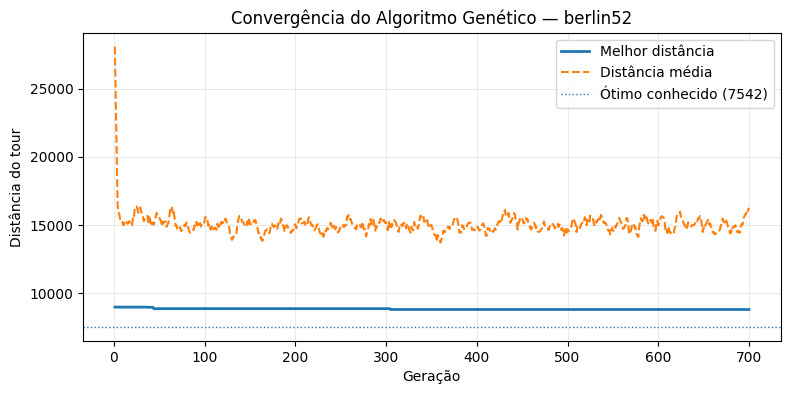

In [14]:
benchmark_para_plotar = "berlin52"  # altere para "burma14" ou "kroA100"

if benchmark_para_plotar in todos_tours:
    historico = todos_tours[benchmark_para_plotar]["historico_ag"]

    if historico["melhor"]:
        geracoes = range(1, len(historico["melhor"]) + 1)

        plt.figure(figsize=(9, 4))
        plt.plot(geracoes, historico["melhor"], linewidth=2, label="Melhor distância")
        plt.plot(geracoes, historico["medio"], linewidth=1.5, linestyle="--", label="Distância média")

        otimo = OTIMOS_CONHECIDOS.get(benchmark_para_plotar)
        if otimo is not None:
            plt.axhline(otimo, linewidth=1, linestyle=":", label=f"Ótimo conhecido ({otimo})")

        plt.xlabel("Geração")
        plt.ylabel("Distância do tour")
        plt.title(f"Convergência do Algoritmo Genético — {benchmark_para_plotar}")
        plt.grid(True, linewidth=0.4, alpha=0.5)
        plt.legend()
        plt.show()
else:
    print("Benchmark não encontrado nos resultados executados.")

## 14. Plotar a melhor rota encontrada

Esta célula plota a melhor rota encontrada para um benchmark específico, desde que o arquivo tenha coordenadas.

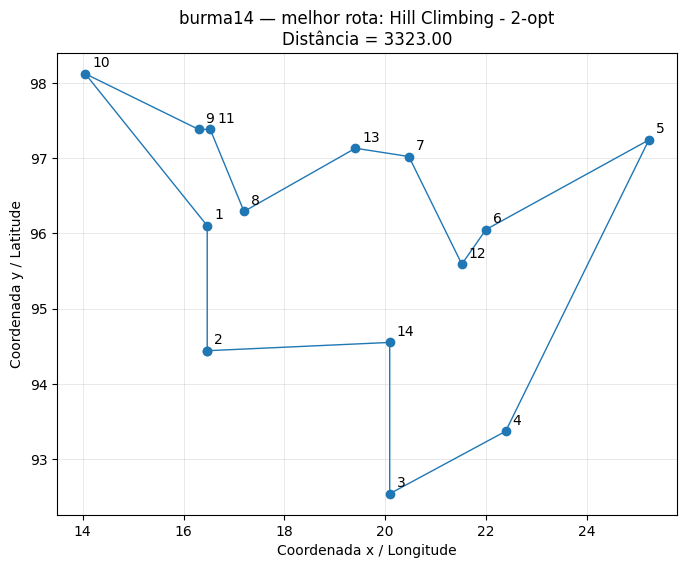

In [15]:
benchmark_rota = "burma14"  # altere para "berlin52" ou "kroA100"

if benchmark_rota in todos_tours:
    problema = carregar_problema_tsp(DATA_DIR / f"{benchmark_rota}.tsp")

    # Seleciona a melhor linha da tabela para este benchmark.
    linhas_bm = tabela_resultados[tabela_resultados["benchmark"] == benchmark_rota]
    melhor_algoritmo = linhas_bm.sort_values("distancia").iloc[0]["algoritmo"]

    mapa_algoritmos = {
        "Guloso - Nearest Neighbor": "guloso",
        "Hill Climbing - 2-opt": "2opt",
        "Simulated Annealing": "sa",
        "Threshold Accepting": "ta",
        "Algoritmo Genético - OX + swap": "ag",
    }

    chave = mapa_algoritmos[melhor_algoritmo]
    melhor_tour = todos_tours[benchmark_rota][chave]

    plotar_tour(problema, melhor_tour, f"{benchmark_rota} — melhor rota: {melhor_algoritmo}")
else:
    print("Benchmark não encontrado nos resultados executados.")

## 15. Interpretação dos resultados

Ao analisar a tabela final, observe:

- O **Nearest Neighbor** é rápido, mas geralmente não encontra a melhor rota.
- O **2-opt** costuma melhorar bastante a rota gulosa.
- O **Simulated Annealing** e o **Threshold Accepting** podem escapar de mínimos locais.
- O **Algoritmo Genético** trabalha com população de rotas e pode gerar boas soluções, mas custa mais tempo computacional.
- O **gap percentual** mostra o quanto a solução ficou acima do ótimo conhecido.

Quanto menor a distância e menor o gap, melhor o resultado.